# K-Means Clustering

In [1]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# --- 11. SURVIVAL ANALYSIS (Industry Standard) ---
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

In [3]:
np.random.seed(2)

# First cluster
X1 = np.random.normal(size=(25, 2))

# Second cluster with mean shift
X2 = np.random.normal(loc=3, size=(25, 2))

# Combine into one dataset
X = np.vstack([X1, X2])

# True labels (for comparison only)
true_labels = np.array([0]*25 + [1]*25)

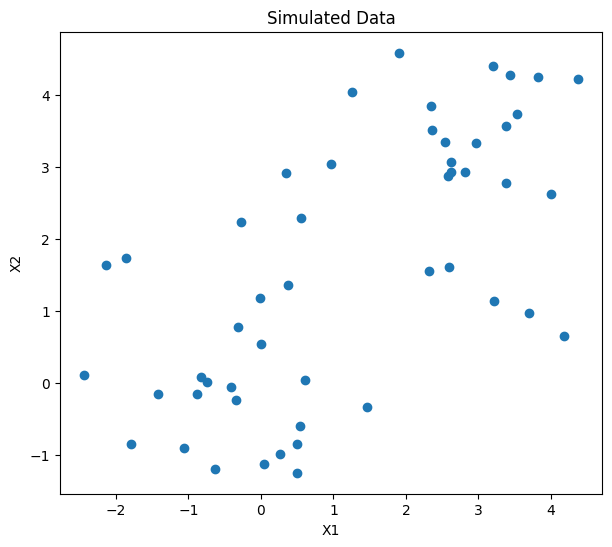

In [4]:
plt.figure(figsize=(7, 6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Data")

plt.show()

In [5]:
kmeans = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=2
)

kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,2
,copy_x,True
,algorithm,'lloyd'


In [6]:
cluster_labels = kmeans.labels_

In [7]:
centers = kmeans.cluster_centers_
print(centers)

[[-0.45293017  0.04331098]
 [ 2.72997495  3.01836148]]


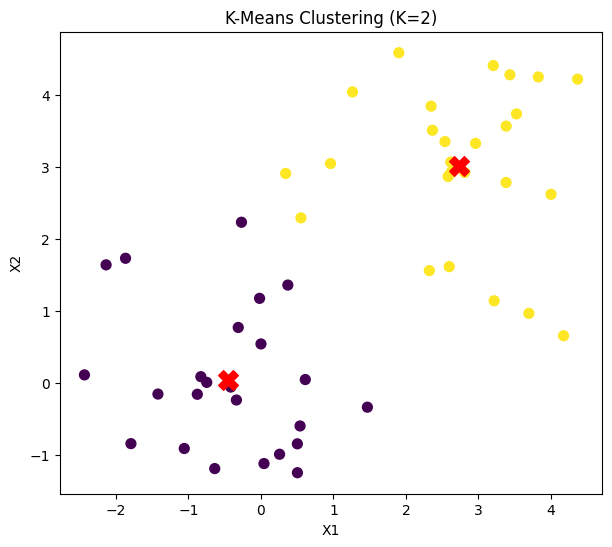

In [8]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=50
)

# Plot centroids
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    marker="X"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("K-Means Clustering (K=2)")

plt.show()

In [9]:
pd.crosstab(cluster_labels, true_labels)

col_0,0,1
row_0,,
0,24,0
1,1,25


## 1. Optimization Problem

K-means clustering minimizes the **within-cluster sum of squares (WCSS)**:

$$
\sum_{k=1}^{K}
\sum_{i \in C_k}
\|x_i - \mu_k\|^2
$$

where:

- $C_k$ = set of observations belonging to cluster $k$
- $\mu_k$ = centroid (mean vector) of cluster $k$

---

## 2. Geometric Meaning

K-means attempts to:

- make observations close to their assigned centroid
- produce compact, spherical clusters
- minimize within-cluster variability

Because squared Euclidean distance is used, observations far from the centroid are penalized heavily.

---

## 3. The K-Means Algorithm

The algorithm proceeds iteratively.

---

### Step 1 — Initialize Centroids

Choose $K$ initial centroids randomly.

These are initial guesses for the cluster centers.

---

### Step 2 — Assignment Step

Assign each observation to the nearest centroid:

$$
\text{cluster}(x_i)
=
\arg\min_k
\|x_i - \mu_k\|^2
$$

This partitions the data into $K$ clusters.

---

### Step 3 — Update Step

Recompute each centroid using the mean of the observations assigned to that cluster:

$$
\mu_k
=
\frac{1}{|C_k|}
\sum_{i \in C_k} x_i
$$

where:

- $|C_k|$ = number of observations in cluster $k$

---

### Step 4 — Repeat

Repeat:

1. assignment step
2. update step

until convergence.

Typically convergence occurs when:
- cluster assignments stop changing, or
- centroid movement becomes negligible.

---

## 4. Why `n_init=20` Matters

K-means depends heavily on initialization.

Different random starting centroids can produce:
- different local minima
- different cluster assignments

Therefore:

```python
n_init=20
```

means:

- run K-means 20 separate times
- use different random initializations
- keep the solution with the lowest objective value

This is extremely important in practice because K-means optimization is non-convex.

---

## 5. Conceptual Difference vs Hierarchical Clustering

| K-Means | Hierarchical Clustering |
|---|---|
| Must choose $K$ beforehand | No need to specify $K$ initially |
| Optimizes an objective function | Greedy merging procedure |
| Produces a flat partition | Produces a hierarchy |
| Assumes compact spherical clusters | More flexible cluster shapes |
| Sensitive to initialization | Deterministic (given linkage rule) |

---

## 6. Importance of Scaling

K-means uses Euclidean distance:

$$
d(x_i, x_j)
=
\sqrt{
\sum_{p=1}^{P}
(x_{ip}-x_{jp})^2
}
$$

Therefore variables with larger numerical scales dominate the distance calculation.

## 7. Standardization

To avoid scale dominance, variables are often standardized:

$$
z
=
\frac{x - \mu}{\sigma}
$$

where:
- $\mu$ = variable mean
- $\sigma$ = variable standard deviation

After standardization:
- mean becomes 0
- variance becomes 1

This ensures variables contribute more equally to Euclidean distance.

---

## 8. Standardization in Python

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

---

## 9. Deep Geometric Interpretation

Without scaling, K-means minimizes:

$$
\sum_{k=1}^{K}
\sum_{i \in C_k}
\sum_{j=1}^{p}
(x_{ij} - \mu_{kj})^2
$$

Variables with larger variance automatically contribute more to the objective function.

Therefore scaling changes:
- the geometry of the feature space
- the optimization landscape
- the resulting clusters themselves

---

## 10. Connection to PCA

This is the same issue encountered in PCA.

Without standardization:
- high-variance variables dominate principal components

Therefore both:
- PCA
- K-means

are highly sensitive to feature scale because both fundamentally rely on Euclidean geometry.

# Inertia (Within-Cluster Sum of Squares)

In [15]:
inertias = []

K_range = range(1, 11)

for K in K_range:
    kmeans = KMeans(
        n_clusters=K,
        n_init=20,
        random_state=2
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

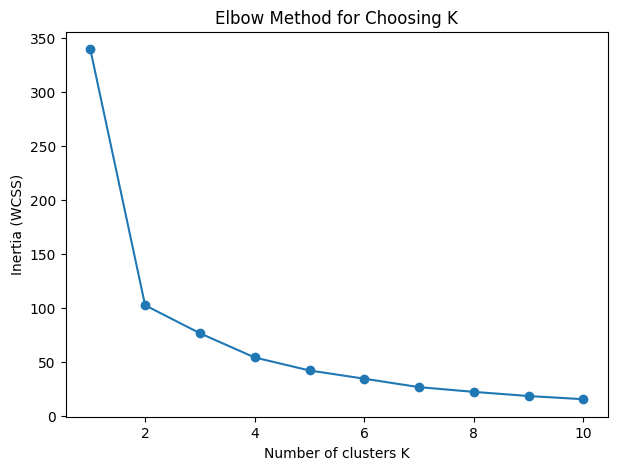

In [16]:
plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Choosing K")
plt.show()

In K-means clustering, the fundamental quantity being minimized is the **inertia**, also called the **within-cluster sum of squares (WCSS)**.

## Definition

For a clustering into $K$ clusters $C_1, \dots, C_K$, inertia is defined as:

$$
\text{Inertia} =
\sum_{k=1}^{K}
\sum_{i \in C_k}
\|x_i - \mu_k\|^2
$$

where:
- $x_i$ is an observation
- $\mu_k$ is the centroid of cluster $k$
- $C_k$ is the set of observations assigned to cluster $k$

---

## Interpretation

Inertia measures:

> the total squared distance between each point and its assigned cluster center.

So it quantifies **cluster compactness**:

- low inertia → points are close to their centroids → tight clusters
- high inertia → points are spread out → loose clusters

---

## Key Properties

### 1. Always decreases with $K$
As the number of clusters increases:

- clusters become smaller
- centroids better fit local structure
- therefore inertia decreases

Formally:
$$
\text{Inertia}(K+1) \leq \text{Inertia}(K)
$$

---

### 2. Extreme cases

- $K = 1$: all points in one cluster → maximum inertia
- $K = n$: each point is its own cluster → inertia = 0

---

## Role in Model Selection (Elbow Method)

Plotting inertia against $K$ typically yields a decreasing curve.

The **elbow point** is where the marginal gain in reducing inertia starts diminishing:

> This is often used as a heuristic for choosing $K$.

---

## Limitation

> Inertia always improves with larger $K$, so it does not penalize model complexity. This makes it insufficient as a standalone criterion for selecting the number of clusters.

# Silhouette Score — Cluster Quality via Separation vs Cohesion

In [17]:
sil_scores = []

K_range = range(2, 11)  # silhouette undefined for K=1

for K in K_range:
    kmeans = KMeans(
        n_clusters=K,
        n_init=20,
        random_state=2
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

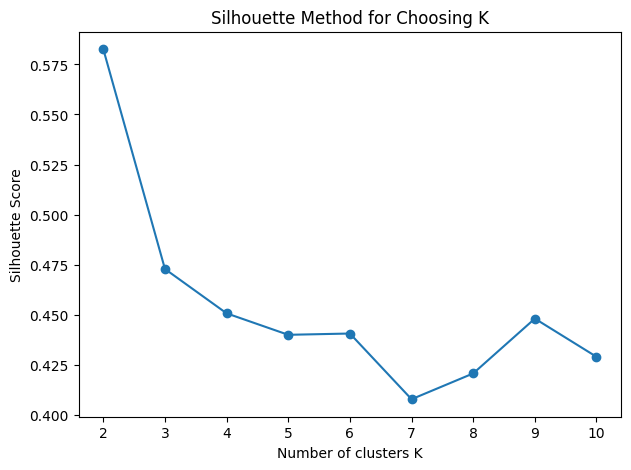

In [18]:
plt.figure(figsize=(7,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Choosing K")
plt.show()

The silhouette score evaluates how well each observation fits within its assigned cluster compared to other clusters.

It combines **within-cluster cohesion** and **between-cluster separation**.

---

For each observation $i$, define:

### 1. Cohesion (within-cluster distance)
$$
a(i) = \frac{1}{|C_i| - 1} \sum_{j \in C_i, j \neq i} d(i, j)
$$

This measures the **average distance from point \(i\) to all other points in its own cluster**.

---

### 2. Separation (nearest other cluster distance)
$$
b(i) = \min_{k \neq C_i} \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j)
$$

This measures the **average distance from point \(i\) to the closest other cluster**.

---

### 3. Silhouette value

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

---

## Interpretation

The silhouette score lies in:

$$
-1 \leq s(i) \leq 1
$$

### Meaning:

- $s(i) \approx 1$: well-clustered (far from other clusters, close to own)
- $s(i) \approx 0$: on cluster boundary
- $s(i) < 0$: likely misclassified

---

## Overall silhouette score

The global score is the average over all observations:

$$
S = \frac{1}{n} \sum_{i=1}^n s(i)
$$

---

## Interpretation at dataset level

- High silhouette score → well-separated, compact clusters
- Low silhouette score → overlapping or poorly defined clusters

---

## Strengths

- Captures both **cohesion and separation**
- Provides a single interpretable metric
- Useful for comparing different values of $K$

---

## Limitations

- Assumes meaningful distance geometry (Euclidean structure)
- Can fail for:
  - non-convex clusters
  - clusters with unequal density
  - high-dimensional noisy data

# Additional K-Means Diagnostics and Interpretation Tools

This section introduces three complementary tools for analysing K-means clustering beyond simple fitting: the **Gap Statistic**, **Voronoi decision regions**, and **cluster profiling**. Together, they provide insight into model selection, geometric structure, and statistical interpretation of clusters.

## Gap Statistic — Model-Based Choice of $K$

The Gap Statistic provides a principled way to select the number of clusters by comparing observed clustering performance to that expected under a null (no structure) reference distribution.

For a given $K$, define:

$$
\text{Gap}(K) = \log(W_K^{\text{null}}) - \log(W_K^{\text{real}})
$$

where:
- $W_K^{\text{real}}$: within-cluster sum of squares (inertia) on the observed data
- $W_K^{\text{null}}$: expected inertia under uniformly distributed data

#### Interpretation

- Large Gap value → strong evidence of cluster structure
- Small Gap value → clustering similar to random noise
- The optimal $K$ is typically where the Gap is maximised


In [19]:
def gap_statistic(X, K, B=10):
    km = KMeans(n_clusters=K, n_init=20, random_state=2)
    km.fit(X)
    W_real = km.inertia_

    n, d = X.shape
    W_rand = []

    for b in range(B):
        X_rand = np.random.uniform(X.min(axis=0), X.max(axis=0), size=(n, d))
        km_rand = KMeans(n_clusters=K, n_init=10, random_state=b)
        km_rand.fit(X_rand)
        W_rand.append(km_rand.inertia_)

    W_rand = np.mean(W_rand)

    return np.log(W_rand) - np.log(W_real)

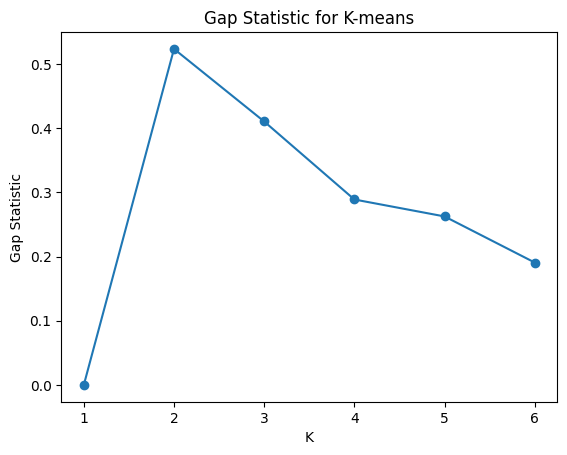

In [20]:
K_range = range(1, 7)
gaps = []

for K in K_range:
    if K == 1:
        gaps.append(0)  # undefined baseline
    else:
        gaps.append(gap_statistic(X, K))

plt.plot(K_range, gaps, marker='o')
plt.xlabel("K")
plt.ylabel("Gap Statistic")
plt.title("Gap Statistic for K-means")
plt.show()

# Voronoi Decision Regions (K-means geometry)

In [22]:
kmeans = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=2
)

kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,2
,copy_x,True
,algorithm,'lloyd'


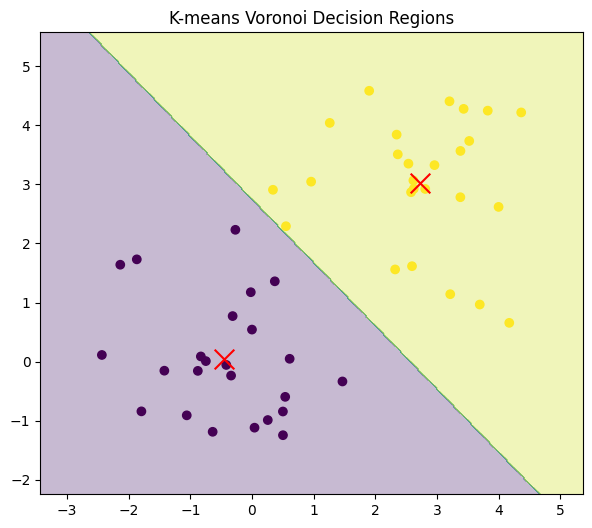

In [23]:
h = 0.02

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='red', marker='x', s=200)

plt.title("K-means Voronoi Decision Regions")
plt.show()

## Key property

Each observation is assigned according to:

$$
\text{cluster}(x_i) = \arg\min_k \|x_i - \mu_k\|^2
$$

This induces a partition of the space into convex regions.

---

## Geometric interpretation

- Each centroid defines a region of influence
- Boundaries between clusters are linear hyperplanes
- The space is fully partitioned into Voronoi cells


# Cluster Profiling

In [24]:
kmeans = KMeans(n_clusters=2, n_init=20, random_state=2)
labels = kmeans.fit_predict(X)

In [25]:
df = pd.DataFrame(X, columns=["x1", "x2"])
df["cluster"] = labels

In [27]:
summary_mean = df.groupby("cluster").mean()
summary_std = df.groupby("cluster").std()

display(summary_mean)
display(summary_std)

,x1,x2
cluster,,
0,-0.452930,0.043311
1,2.729975,3.018361


,x1,x2
cluster,,
0,0.974125,0.995059
1,1.057935,1.097387


For each cluster $k$, compute:

- Mean:
$$
\bar{x}_k = \frac{1}{|C_k|} \sum_{i \in C_k} x_i
$$

- Standard deviation (within-cluster variability)

- Cluster size:
$$
|C_k|
$$

---

## Interpretation

Cluster profiling transforms unsupervised learning into a descriptive statistical analysis:

- cluster centroids represent typical observations
- within-cluster variance measures homogeneity
- cluster sizes indicate prevalence of each group
